In [ ]:
#Gamestop stock price vs Revenue and Tesla stock price vs Revenue:

In [58]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [65]:
def make_graph(stock_data, revenue_data, stock):
    fig = make_subplots(rows=2, cols=1, shared_xaxes=True, subplot_titles=("Historical Share Price", "Historical Revenue"), vertical_spacing = .3)
    stock_data_specific = stock_data[stock_data.Date <= '2021--06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    fig.add_trace(go.Scatter(x=pd.to_datetime(stock_data_specific.Date), y=stock_data_specific.Close.astype("float"), name="Share Price"), row=1, col=1)
    fig.add_trace(go.Scatter(x=pd.to_datetime(revenue_data_specific.Date), y=revenue_data_specific.Revenue.astype("float"), name="Revenue"), row=2, col=1)
    fig.update_xaxes(title_text="Date", row=1, col=1)
    fig.update_xaxes(title_text="Date", row=2, col=1)
    fig.update_yaxes(title_text="Price ($US)", row=1, col=1)
    fig.update_yaxes(title_text="Revenue ($US Millions)", row=2, col=1)
    fig.update_layout(showlegend=False,
    height=900,
    title=stock,
    xaxis_rangeslider_visible=True)
    fig.show()

In [60]:
Gamestop_data=yf.Ticker("GME")
Gamestop_data_history=Gamestop_data.history(period="max")
print(Gamestop_data_history)

                                Open       High        Low      Close  \
Date                                                                    
2002-02-13 00:00:00-05:00   1.620129   1.693350   1.603296   1.691667   
2002-02-14 00:00:00-05:00   1.712707   1.716074   1.670626   1.683250   
2002-02-15 00:00:00-05:00   1.683250   1.687458   1.658001   1.674834   
2002-02-19 00:00:00-05:00   1.666417   1.666417   1.578047   1.607504   
2002-02-20 00:00:00-05:00   1.615921   1.662210   1.603296   1.662210   
...                              ...        ...        ...        ...   
2026-06-08 00:00:00-04:00  21.770000  22.270000  21.650000  22.260000   
2026-06-09 00:00:00-04:00  22.280001  22.459999  21.920000  22.280001   
2026-06-10 00:00:00-04:00  22.020000  22.650000  21.900000  22.420000   
2026-06-11 00:00:00-04:00  22.389999  22.440001  21.940001  22.180000   
2026-06-12 00:00:00-04:00  22.059999  22.160000  21.500000  21.770000   

                             Volume  Dividends  St

In [61]:
Gamestop_data_history.reset_index(inplace=True)
Gamestop_data_history.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620129,1.693350,1.603296,1.691667,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716074,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683250,1.687458,1.658001,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666417,1.666417,1.578047,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0


In [ ]:
#Retrieving revenue of company:

In [62]:
Gamestop_url="https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue"

headers = {
    "User-Agent": "Mozilla/5.0"
}
Gme_revenue_data=requests.get(Gamestop_url,headers=headers).text
print(Gme_revenue_data)
Gamestop_soup=BeautifulSoup(Gme_revenue_data,"html.parser")
# print(Gamestop_soup.title)


<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js"> <!--<![endif]-->
    <head>
        <meta charset="utf-8">
        <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
		<link rel="canonical" href="https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue" />
		<title>GameStop Revenue 2012-2026 | GME | MacroTrends</title>
		<link rel="icon" type="image/x-icon" href="/assets/images/icons/FAVICON/macrotrends-favicon-96.png">
		<meta name="description" content="GameStop annual/quarterly revenue history and growth rate from 2012 to 2026. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses 

In [63]:
gme_revenue=pd.DataFrame(columns=["Date","Revenue"])
# tbodies = Gamestop_soup.find_all("tbody")

# print(len(tbodies))
for row in Gamestop_soup.find("tbody").find_all("tr"):
    col=row.find_all("td")
    date=col[0].text
    revenue=col[1].text
    gme_revenue.loc[len(gme_revenue)] = [date, revenue]  
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r",|\$","",regex=True)
gme_revenue.tail()

,Date,Revenue
10,2016,9364
11,2015,9296
12,2014,9040
13,2013,8887
14,2012,9551


In [ ]:
#Graph of Gamestop stock_price vs Revenue

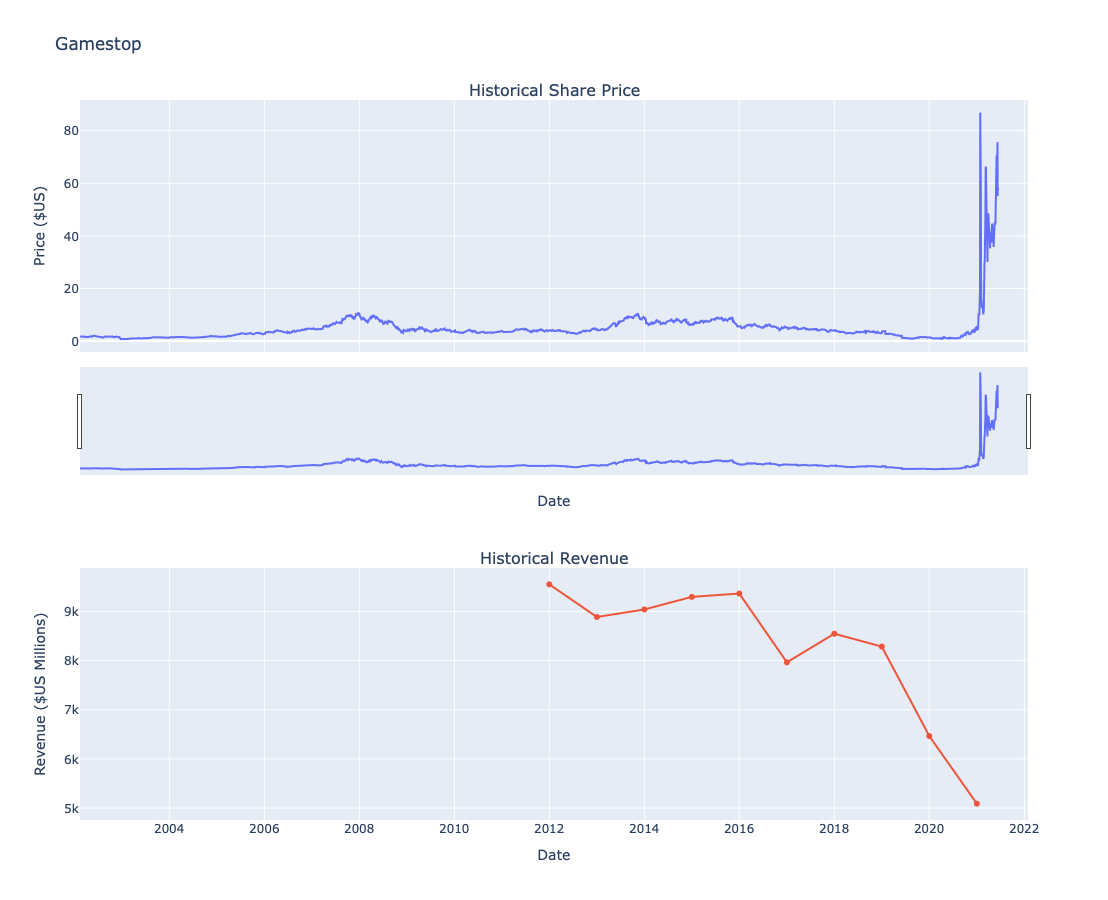

In [66]:
make_graph(Gamestop_data_history,gme_revenue, "Gamestop")

In [ ]:
#Tesla Stock price vs Revenue:

In [40]:
Tesla_stock=yf.Ticker("TSLA")
Tesla_stock_History=Tesla_stock.history(period="max")
print(Tesla_stock_History)

                                 Open        High         Low       Close  \
Date                                                                        
2010-06-29 00:00:00-04:00    1.266667    1.666667    1.169333    1.592667   
2010-06-30 00:00:00-04:00    1.719333    2.028000    1.553333    1.588667   
2010-07-01 00:00:00-04:00    1.666667    1.728000    1.351333    1.464000   
2010-07-02 00:00:00-04:00    1.533333    1.540000    1.247333    1.280000   
2010-07-06 00:00:00-04:00    1.333333    1.333333    1.055333    1.074000   
...                               ...         ...         ...         ...   
2026-06-08 00:00:00-04:00  396.329987  412.940002  394.720001  408.950012   
2026-06-09 00:00:00-04:00  411.029999  418.500000  384.239990  396.679993   
2026-06-10 00:00:00-04:00  391.540009  397.089996  380.149994  381.589996   
2026-06-11 00:00:00-04:00  388.279999  399.540009  380.660004  399.149994   
2026-06-12 00:00:00-04:00  399.489990  406.679993  386.760010  406.429993   

In [41]:
Tesla_stock_History.reset_index(inplace=True)
Tesla_stock_History.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
1,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
3,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
4,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [42]:
#Retrieving Tesla Revenue:
Tesla_url="https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue"
headers1={
"User-Agent": "Mozilla/5.0"
}
Tesla_revenue_data=requests.get(Tesla_url,headers=headers1).text
print(Tesla_revenue_data)
Tesla_soup=BeautifulSoup(Tesla_revenue_data,"html.parser")


<!DOCTYPE html>
<!--[if lt IE 7]>      <html class="no-js lt-ie9 lt-ie8 lt-ie7"> <![endif]-->
<!--[if IE 7]>         <html class="no-js lt-ie9 lt-ie8"> <![endif]-->
<!--[if IE 8]>         <html class="no-js lt-ie9"> <![endif]-->
<!--[if gt IE 8]><!--> <html class="no-js"> <!--<![endif]-->
    <head>
        <meta charset="utf-8">
        <meta http-equiv="X-UA-Compatible" content="IE=edge,chrome=1">
		<link rel="canonical" href="https://www.macrotrends.net/stocks/charts/TSLA/tesla/revenue" />
		<title>Tesla Revenue 2012-2026 | TSLA | MacroTrends</title>
		<link rel="icon" type="image/x-icon" href="/assets/images/icons/FAVICON/macrotrends-favicon-96.png">
		<meta name="description" content="Tesla annual/quarterly revenue history and growth rate from 2012 to 2026. Revenue can be defined as the amount of money a company receives from its customers in exchange for the sales of goods or services.  Revenue is the top line item on an income statement from which all costs and expenses are sub

In [50]:
Tesla_revenue=pd.DataFrame(columns=["Date","Revenue"])
# tbodies1 = Tesla_soup.find_all("tbody")

# print(len(tbodies1))
for row in Tesla_soup.find("tbody").find_all("tr"):
    col=row.find_all("td")
    date=col[0].text
    revenue=col[1].text
    Tesla_revenue.loc[len(Tesla_revenue)] = [date, revenue]  
Tesla_revenue["Revenue"] = Tesla_revenue['Revenue'].str.replace(r",|\$","",regex=True)
Tesla_revenue.tail()   

,Date,Revenue
10,2015,4046
11,2014,3198
12,2013,2013
13,2012,413
14,2011,204


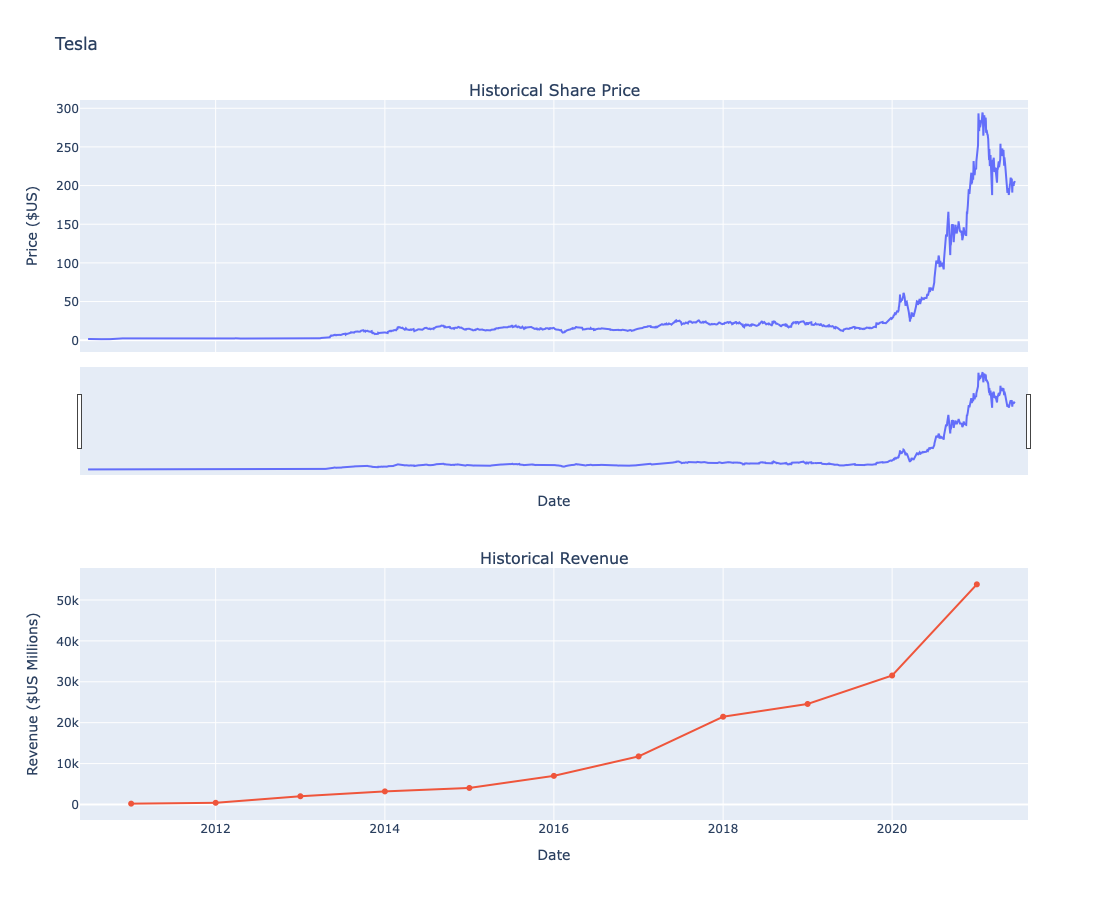

In [67]:
make_graph(Tesla_stock_History,Tesla_revenue,"Tesla")